# SOAP classifier
We first load structures for each phase (liquid, glass, ZIF-4, ZIF-4-cp, ZIF-4-cp-II, ZIF-hPT-II and ZIF-zni) for both force fields (nb-ZIF-FF and MACE).

Then, we calculate the SOAP descriptor for each Zn chemical environment and train the classifier on these vectors.

We also show a practical example on how to use the classifier on a melt-quench simulation.

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.neural_network import MLPClassifier

import ase
import ase.build
from ase import Atoms
from ase import io
from dscribe.descriptors import SOAP

import matplotlib
import matplotlib.pyplot as plt

soap = SOAP(
    species=["Zn", "N", "C", "H"],
    r_cut=9,
    n_max=12,
    l_max=9,
    sigma=0.3,
    rbf="gto",
    periodic=True,
    dtype="float32",
    compression={"mode": "mu2"},
)

def calculate_soap(phase):
    if isinstance(phase,np.ndarray):
        # then the soap is already calculated
        print("input is already a SOAP, we don't need to calculate it :)")
        return phase
    else:
        print("input is not a SOAP, calculating it ...")
        for i, structure in enumerate(phase):
        
            features = soap.create(structure, centers=[atom.index for atom in structure if atom.symbol == 'Zn'])
            feature_list = features.tolist()
            if i==0:
                X=feature_list
            else:
                X = np.vstack([X, feature_list])
        print("done SOAP")
        return X

pipeline_SOAP_classifier = Pipeline([
    ('descriptor', FunctionTransformer(calculate_soap, validate=False)),
    ('scaler', StandardScaler()),                                       
    ('classifier', MLPClassifier(alpha=1, max_iter=1000, random_state=42)),  
    
])

# Loading the structures

In [2]:
phases=['liquid', 'glass', 'ZIF-4','ZIF-4-cp','ZIF-4-cp-II','ZIF-hPT-II','ZIF-zni']


struct={}
for phase in phases:
    struct[phase]=ase.io.read(f'../Structures/MACE/{phase}.extxyz',index=':')
    struct[phase].extend(ase.io.read(f'../Structures/NB-ZIF-FF/{phase}.extxyz',index=':'))


# Calculating the SOAPs 
(this can take a few minutes ...)

The SOAP vectors should have a length of 780

In [3]:
Soaps={}
for key in phases:
    Soaps[key]=calculate_soap(struct[key])

input is not a SOAP, calculating it ...
done SOAP
input is not a SOAP, calculating it ...
done SOAP
input is not a SOAP, calculating it ...
done SOAP
input is not a SOAP, calculating it ...
done SOAP
input is not a SOAP, calculating it ...
done SOAP
input is not a SOAP, calculating it ...
done SOAP
input is not a SOAP, calculating it ...
done SOAP


# Training the classifier
To train the classifier, each phase is associated to a number:

liquid=0,
glass=1, 
ZIF-4=2, 
ZIF-4-cp=3, 
ZIF-4-cp-II=4, 
ZIF-hPT-II=5 
and ZIF-zni=6 

In [4]:
Y_phases={key: len(Soaps[key])*[i] for i, key in enumerate(Soaps)}
X=np.vstack(list(Soaps.values()))
Y=np.concatenate(list(Y_phases.values()))

print(len(Y),len(X))

672320 672320


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)
np.save("X_train.npy",X_train)
np.save("Y_train.npy",Y_train)
np.save("X_test.npy",X_test)
np.save("Y_test.npy",Y_test)

In [7]:
pipeline_SOAP_classifier.fit(X_train, Y_train)
import joblib
joblib.dump(pipeline_SOAP_classifier, 'SOAP_classifier.joblib')

input is already a SOAP, we don't need to calculate it :)


['SOAP_classifier.joblib']

In [8]:
Y_test_predicted=pipeline_SOAP_classifier.predict(X_test)
print(metrics.classification_report(Y_test, Y_test_predicted, digits=6))

input is already a SOAP, we don't need to calculate it :)
              precision    recall  f1-score   support

           0   0.988914  0.970196  0.979466     19125
           1   0.969186  0.981445  0.975277     19132
           2   0.994206  0.999272  0.996733     19232
           3   0.973834  0.975759  0.974796     19224
           4   0.977273  0.975707  0.976489     19347
           5   1.000000  1.000000  1.000000     19224
           6   0.998750  0.999531  0.999140     19180

    accuracy                       0.985989    134464
   macro avg   0.986023  0.985987  0.985986    134464
weighted avg   0.986021  0.985989  0.985986    134464



# How to use the classifier?
We can use the classifier by inputting either a list of structures or the SOAP vectors directly.

For each Zn in the structure, the output is a scalar associated with the predicted structure

Here we use a trajectory of a melt-quench simulation to try out the classifier.

In [9]:
melt_quench=ase.io.read('structure_to_classify/melt_quench.extxyz',index=':')
predicted_phase=pipeline_SOAP_classifier.predict(melt_quench)
predicted_phase=predicted_phase.reshape(-1,128) # we have 128 Zn in each structure

input is not a SOAP, calculating it ...
done SOAP


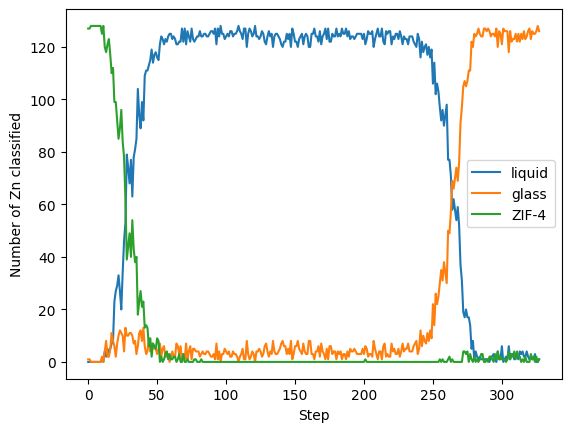

In [10]:
plt.plot(np.sum(predicted_phase==0,axis=1),label='liquid')
plt.plot(np.sum(predicted_phase==1,axis=1),label='glass')
plt.plot(np.sum(predicted_phase==2,axis=1),label='ZIF-4')
plt.xlabel('Step')
plt.ylabel('Number of Zn classified')
plt.legend()